In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

# Cargar todo
daily = pd.read_csv("../data/processed/eurusd_con_sentimiento.csv",
                    index_col=0, parse_dates=True)

with open("../data/processed/fusion_model.pkl", "rb") as f:
    modelo_fusion = pickle.load(f)

print(f"Dataset: {daily.shape}")
print("Modelos cargados.")

Dataset: (4031, 40)
Modelos cargados.


In [2]:
# ── RISK MANAGER — Reglas hard-coded ──────────────────────────

class RiskManager:
    def __init__(self):
        # Parámetros de riesgo
        self.max_loss_per_trade = 0.01      # 1% máximo por operación
        self.max_daily_drawdown = 0.03      # 3% máximo diario
        self.max_position_size = 1.0        # tamaño máximo de posición
        self.min_confidence = 0.55          # convicción mínima para operar
        self.crisis_threshold = 2           # régimen turbulento = estado 2
        self.crisis_size_reduction = 0.5    # reducir tamaño 50% en crisis
        self.spread_max_pips = 0.0003       # 3 pips máximo de spread
        
        # Estado interno
        self.daily_pnl = 0.0
        self.consecutive_losses = 0
        
    def evaluar_señal(self, señal, confianza, regimen, volatilidad, spread=0.0001):
        """
        Evalúa si una señal debe ejecutarse y con qué tamaño.
        Retorna: (ejecutar: bool, tamaño: float, razon: str)
        """
        
        # Regla 1: Spread muy alto
        if spread > self.spread_max_pips:
            return False, 0.0, "VETO: spread muy alto"
        
        # Regla 2: Convicción insuficiente
        if confianza < self.min_confidence:
            return False, 0.0, "VETO: convicción insuficiente"
        
        # Regla 3: Drawdown diario excedido
        if self.daily_pnl < -self.max_daily_drawdown:
            return False, 0.0, "VETO: drawdown diario máximo alcanzado"
        
        # Regla 4: Demasiadas pérdidas consecutivas
        if self.consecutive_losses >= 3:
            return False, 0.0, "VETO: 3 pérdidas consecutivas — pausa"
        
        # Tamaño base
        tamaño = self.max_position_size
        
        # Regla 5: Reducir tamaño en régimen turbulento
        if regimen == self.crisis_threshold:
            tamaño *= self.crisis_size_reduction
            razon = f"EJECUTAR (tamaño reducido 50% — régimen turbulento)"
        else:
            razon = "EJECUTAR (tamaño completo)"
        
        # Regla 6: Reducir tamaño si volatilidad muy alta
        if volatilidad > 0.12:
            tamaño *= 0.7
            razon += " + volatilidad alta (-30%)"
        
        return True, round(tamaño, 2), razon
    
    def actualizar_pnl(self, pnl_trade):
        self.daily_pnl += pnl_trade
        if pnl_trade < 0:
            self.consecutive_losses += 1
        else:
            self.consecutive_losses = 0
    
    def reset_diario(self):
        self.daily_pnl = 0.0

# Test del Risk Manager
rm = RiskManager()

casos_test = [
    {"señal": 1, "confianza": 0.65, "regimen": 0, "volatilidad": 0.07, "desc": "Señal normal"},
    {"señal": 1, "confianza": 0.45, "regimen": 0, "volatilidad": 0.07, "desc": "Baja confianza"},
    {"señal": 1, "confianza": 0.65, "regimen": 2, "volatilidad": 0.13, "desc": "Crisis + vol alta"},
    {"señal": 1, "confianza": 0.65, "regimen": 0, "volatilidad": 0.07, "desc": "Drawdown excedido"},
]

# Simular drawdown en el último caso
rm.daily_pnl = -0.04

print("Test del Risk Manager:")
print("="*60)
for caso in casos_test:
    ejecutar, tamaño, razon = rm.evaluar_señal(
        caso['señal'], caso['confianza'], 
        caso['regimen'], caso['volatilidad']
    )
    print(f"\n{caso['desc']}:")
    print(f"  → {razon}")
    print(f"  → Tamaño: {tamaño}")

Test del Risk Manager:

Señal normal:
  → VETO: drawdown diario máximo alcanzado
  → Tamaño: 0.0

Baja confianza:
  → VETO: convicción insuficiente
  → Tamaño: 0.0

Crisis + vol alta:
  → VETO: drawdown diario máximo alcanzado
  → Tamaño: 0.0

Drawdown excedido:
  → VETO: drawdown diario máximo alcanzado
  → Tamaño: 0.0


In [3]:
print("Test del Risk Manager:")
print("="*60)

# Caso 1: Señal normal
rm1 = RiskManager()
ejecutar, tamaño, razon = rm1.evaluar_señal(0.65, 0.65, 0, 0.07)
print(f"\nSeñal normal:")
print(f"  → {razon} | Tamaño: {tamaño}")

# Caso 2: Baja confianza
rm2 = RiskManager()
ejecutar, tamaño, razon = rm2.evaluar_señal(1, 0.45, 0, 0.07)
print(f"\nBaja confianza:")
print(f"  → {razon} | Tamaño: {tamaño}")

# Caso 3: Crisis + volatilidad alta
rm3 = RiskManager()
ejecutar, tamaño, razon = rm3.evaluar_señal(1, 0.65, 2, 0.13)
print(f"\nCrisis + vol alta:")
print(f"  → {razon} | Tamaño: {tamaño}")

# Caso 4: Drawdown excedido
rm4 = RiskManager()
rm4.daily_pnl = -0.04
ejecutar, tamaño, razon = rm4.evaluar_señal(1, 0.65, 0, 0.07)
print(f"\nDrawdown excedido:")
print(f"  → {razon} | Tamaño: {tamaño}")

# Caso 5: 3 pérdidas consecutivas
rm5 = RiskManager()
rm5.consecutive_losses = 3
ejecutar, tamaño, razon = rm5.evaluar_señal(1, 0.65, 0, 0.07)
print(f"\n3 pérdidas consecutivas:")
print(f"  → {razon} | Tamaño: {tamaño}")

Test del Risk Manager:

Señal normal:
  → EJECUTAR (tamaño completo) | Tamaño: 1.0

Baja confianza:
  → VETO: convicción insuficiente | Tamaño: 0.0

Crisis + vol alta:
  → EJECUTAR (tamaño reducido 50% — régimen turbulento) + volatilidad alta (-30%) | Tamaño: 0.35

Drawdown excedido:
  → VETO: drawdown diario máximo alcanzado | Tamaño: 0.0

3 pérdidas consecutivas:
  → VETO: 3 pérdidas consecutivas — pausa | Tamaño: 0.0


In [6]:
# Seleccionar solo las columnas necesarias sin duplicar
cols_necesarias = list(set(features_fusion + ['Close', 'returns']))
data = daily[cols_necesarias].dropna()
X_array = data[features_fusion].values

señales = modelo_fusion.predict(X_array)
confianzas = modelo_fusion.predict_proba(X_array)[:, 1]

rm = RiskManager()
resultados = []

for i in range(len(data)):
    señal = señales[i]
    confianza = confianzas[i]
    regimen = data['regime'].iloc[i]
    volatilidad = data['volatility_20'].iloc[i]
    ret = data['returns'].iloc[i]
    
    ejecutar, tamaño, razon = rm.evaluar_señal(
        señal, confianza, regimen, volatilidad
    )
    
    if ejecutar:
        posicion = tamaño if señal == 1 else -tamaño
    else:
        posicion = 0
    
    retorno_estrategia = posicion * ret
    rm.actualizar_pnl(retorno_estrategia)
    rm.reset_diario()
    
    resultados.append({
        'fecha': data.index[i],
        'señal': señal,
        'confianza': confianza,
        'ejecutar': ejecutar,
        'tamaño': tamaño,
        'retorno': retorno_estrategia
    })

df_resultados = pd.DataFrame(resultados).set_index('fecha')

rets = df_resultados['retorno']
cum = (1 + rets).cumprod()
sharpe = rets.mean() / rets.std() * np.sqrt(252)
max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
operaciones = (df_resultados['ejecutar'] == True).sum()

print("="*50)
print("KRONOS — Sistema completo con Risk Manager")
print("="*50)
print(f"Operaciones ejecutadas: {operaciones}/{len(df_resultados)}")
print(f"Tasa de ejecución: {operaciones/len(df_resultados)*100:.1f}%")
print(f"Retorno total: {(cum.iloc[-1]-1)*100:.1f}%")
print(f"Sharpe ratio: {sharpe:.3f}")
print(f"Max drawdown: {max_dd*100:.1f}%")

KRONOS — Sistema completo con Risk Manager
Operaciones ejecutadas: 1353/4031
Tasa de ejecución: 33.6%
Retorno total: -9.1%
Sharpe ratio: -0.139
Max drawdown: -20.7%


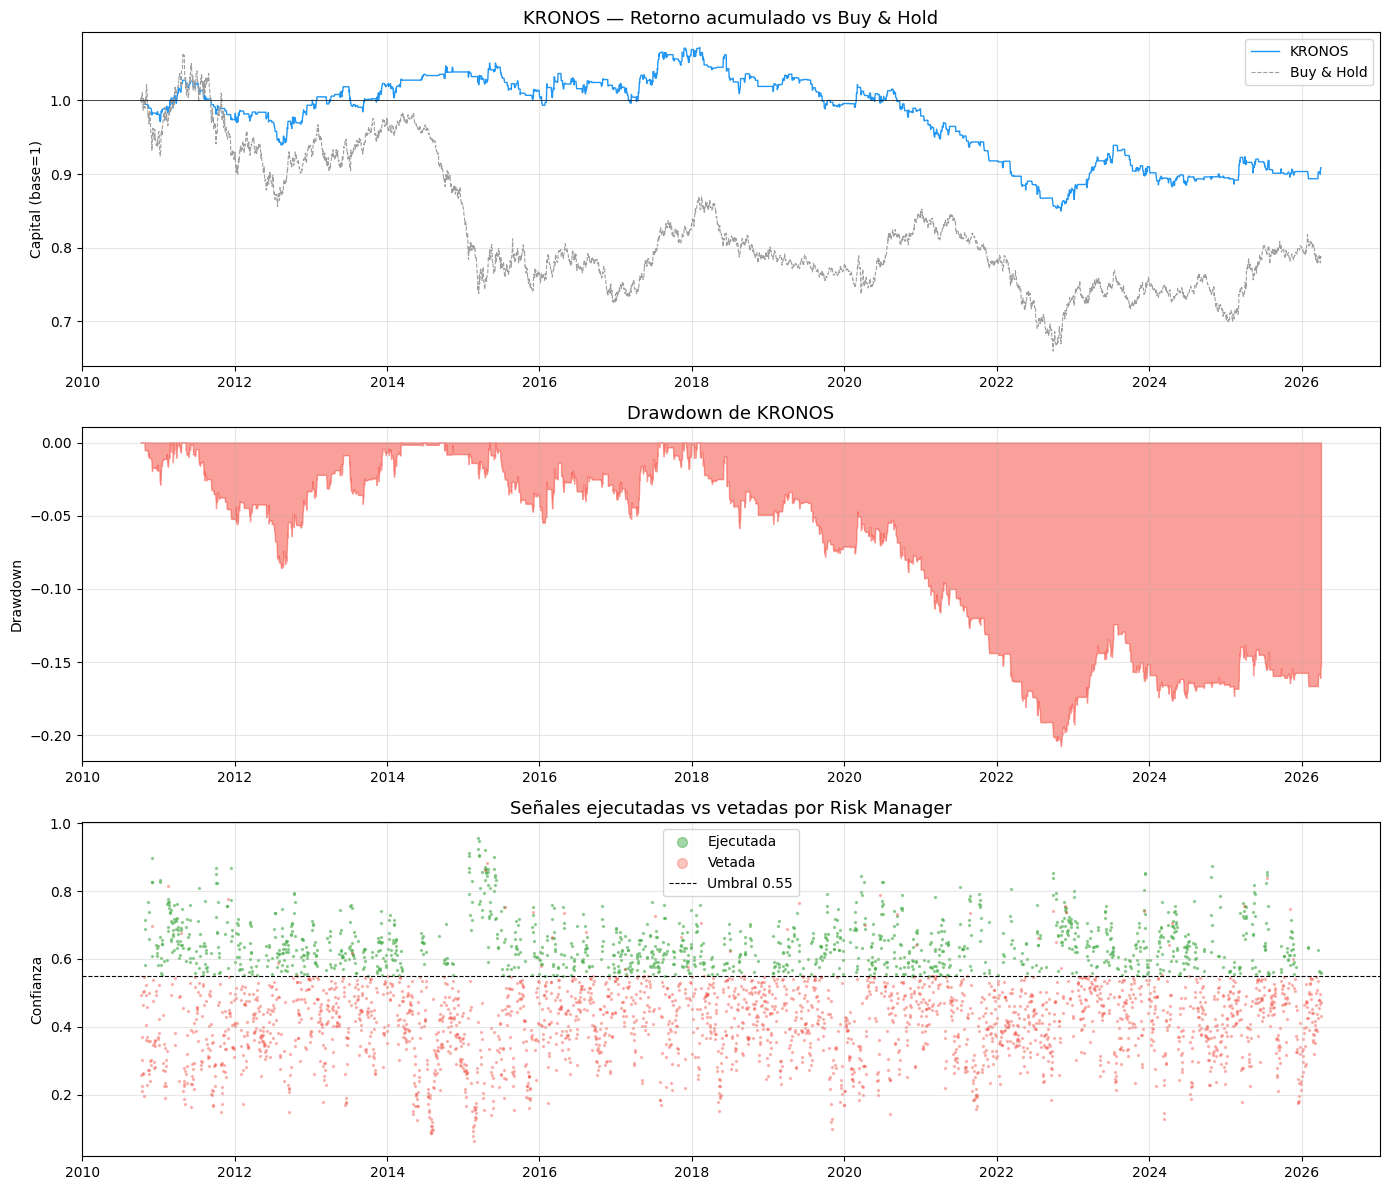

Gráfica guardada.


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Retorno acumulado
bh_cum = (1 + data['returns']).cumprod()
axes[0].plot(df_resultados.index, cum, color='#2196F3', linewidth=1, label='KRONOS')
axes[0].plot(data.index, bh_cum, color='#9E9E9E', linewidth=0.8, linestyle='--', label='Buy & Hold')
axes[0].axhline(1, color='black', linewidth=0.5)
axes[0].set_title('KRONOS — Retorno acumulado vs Buy & Hold', fontsize=13)
axes[0].set_ylabel('Capital (base=1)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
drawdown = (cum - cum.cummax()) / cum.cummax()
axes[1].fill_between(df_resultados.index, drawdown, 0, color='#F44336', alpha=0.5)
axes[1].set_title('Drawdown de KRONOS', fontsize=13)
axes[1].set_ylabel('Drawdown')
axes[1].grid(True, alpha=0.3)

# Operaciones ejecutadas vs vetadas
axes[2].scatter(df_resultados.index[df_resultados['ejecutar']==True],
                df_resultados['confianza'][df_resultados['ejecutar']==True],
                c='#4CAF50', s=2, label='Ejecutada', alpha=0.5)
axes[2].scatter(df_resultados.index[df_resultados['ejecutar']==False],
                df_resultados['confianza'][df_resultados['ejecutar']==False],
                c='#F44336', s=2, label='Vetada', alpha=0.3)
axes[2].axhline(0.55, color='black', linewidth=0.8, linestyle='--', label='Umbral 0.55')
axes[2].set_title('Señales ejecutadas vs vetadas por Risk Manager', fontsize=13)
axes[2].set_ylabel('Confianza')
axes[2].legend(markerscale=5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/10_sistema_completo.png', dpi=150)
plt.show()
print("Gráfica guardada.")